In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.datasets._samples_generator import make_blobs

In [2]:
X,Y=make_blobs(n_samples=300,centers=2,n_features=2,cluster_std=5,random_state=42)

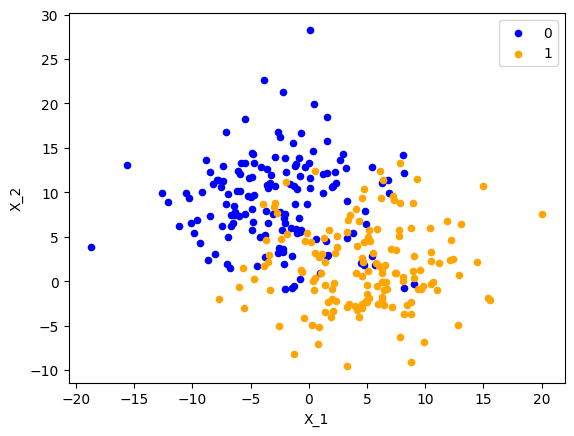

In [3]:
df = pd.DataFrame(dict(x=X[:,0], y=X[:,1], label=Y))
colors = {0:'blue', 1:'orange'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.show()

In [4]:
#splitting into branches
def next_batch(X,Y,batch_size):
    for i in np.arange(0,X.shape[0],batch_size):
        yield (X[i:i+batch_size],Y[i:i+batch_size])

In [5]:
#adding the columns of one's
X=np.c_[np.ones((X.shape[0])),X]
X.shape

(300, 3)

In [6]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [7]:
#model
def hx(W,X):
    return sigmoid(np.dot(X,W))

In [8]:
#cost function
def cost(W,X,Y):
    y_pred=hx(W,X)
    return -1*sum(Y*np.log(y_pred)+(1-Y)*np.log(1-y_pred))

In [9]:
#Stochstic gradient descent
def grad(W,X,Y):
    y_pred=hx(W,X)
    A=(Y*(1-y_pred)-(1-Y)*y_pred)
    g=-1*np.dot(A.T,X)
    return g

In [10]:
def sgd(w_new,w_prev,lr,batch_size,epochs):
    X_,Y_=shuffle(X,Y,random_state=0)
    for e in range(epochs):
        epoch_loss=[]
        X_,Y_=shuffle(X_,Y_,random_state=0)
        for(batchX,batchY) in next_batch(X_,Y_,batch_size):
            w_prev=w_new
            epoch_loss.append(cost(w_prev,batchX,batchY))
            gradient=grad(w_prev,batchX,batchY)
            w_new=w_prev-lr*gradient
        print(np.average(epoch_loss))
    return w_new




In [11]:
W=np.random.uniform(size=(X.shape[1],))
W.shape

(3,)

In [12]:
print(W)

[0.78497715 0.19811065 0.02259011]


In [13]:
W=sgd(W,W,.009,32,200)
print(W)

14.67949677123415
11.561241270002338
11.807577055931194
12.316264856822146
12.369003206282601
11.723007823965903
10.782332295430392
10.848747546933804
12.450783128891372
11.151450783723284
11.511822091217276
11.603240928074573
10.939310580494285
13.004454373623222
10.58142155010862
11.610476549676864
11.118656981992325
11.5518548656013
11.283138762348868
10.81081236188869
10.911850277329682
10.793407565407652
11.888053530945434
11.613579819701538
13.726983435726172
10.77077019954662
13.778262623793267
13.3615805526176
11.082525694319921
11.507334589014139
10.911869854649392
11.048266101012562
11.958558902606205
12.381146333558476
11.061758883543565
13.313141743902174
13.465926464551583
10.630623945930633
11.120117114116857
12.295129661693242
10.881449040935786
11.415303020858671
10.53747752038019
10.030111435653469
11.42642170650226
11.332690715558552
12.599319064821502
12.351190723505407
12.376705536161708
11.151892599272935
10.373870627982583
10.28616861317579
12.774490764587444
11.5

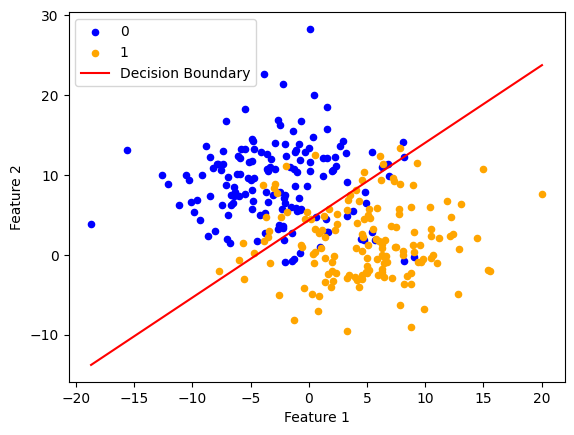

In [14]:
# Use index 1 and 2 because index 0 is now the bias (constant 1)
df = pd.DataFrame(dict(x=X[:, 1], y=X[:, 2], label=Y))
colors = {0: 'blue', 1: 'orange'}
fig, ax = plt.subplots()

grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])

# The decision boundary formula: W0 + W1*x + W2*y = 0
# Solved for y: y = (-W0 - W1*x) / W2
def my_formula(x):
    return (-W[0] - W[1]*x) / W[2]

# Adjusted range to match the scale of your blob data (e.g., -15 to 15)
x_vals = np.linspace(df.x.min(), df.x.max(), 100)
plt.plot(x_vals, my_formula(x_vals), color='red', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()